# 04 · Attention transfer for Student-120

This notebook implements the next KD family from Zagoruyko and Komodakis, *Paying More Attention
to Attention*. It compares a corrected same-view hard-label control with a student trained to
match one spatial teacher attention map. Response KD is intentionally excluded so the measured
change belongs to attention transfer.

Both Stage-B branches start from the same Stage-A checkpoint, use freshly constructed augmentation
with identical seeds, and preserve the exact deployable Student-120 graph.

## Experimental isolation

```mermaid
flowchart LR
 I[One RGB image] --> A[Deterministic-policy shared augmentation]
 A --> T[Teacher 160x160 frozen]
 A --> S[Student 120x120 trainable]
 T --> TA[Teacher late attention]
 S --> SA[Student late attention]
 TA --> L[Normalized spatial AT loss]
 SA --> L
 Y[Hard VWW label] --> H[Hard BCE]
 H --> O[Student update only]
 L --> O
 O --> E[Student-only inference graph]
```

The primary comparison is `attention_control` versus `attention_transfer`. The teacher, feature
taps, attention maps, and loss exist only during training.

## Paper-to-code traceability

The paper forms spatial attention by summing powered activation magnitudes over channels and
normalizing the resulting vector. For feature tensor `F`:

$$A(F)=\sum_c |F_c|^2, \qquad \hat A(F)=A(F)/(\|A(F)\|_2+\epsilon)$$

Teacher attention is resized to the student spatial resolution before normalization. The loss is:

$$L=L_{hard}+\beta\|\hat A_s-\hat A_t\|_2^2+L_{reg}$$

Rather than copying a coefficient from another architecture, this notebook calibrates `beta` once
so the initial weighted AT gradient norm is 10% of the hard-label gradient norm.

## 1 · Environment and immutable contract

In [1]:
import os
from pathlib import Path
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/vww-matplotlib")
ROOT=Path.cwd()
while not (ROOT/"configs").exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
assert (ROOT/"configs").exists()
import sys
if str(ROOT/"src") not in sys.path: sys.path.insert(0,str(ROOT/"src"))

In [2]:
import hashlib, json, random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import display
from sklearn.metrics import average_precision_score, f1_score
from vww_esp32.evaluation import classification_metrics, expected_calibration_error, select_threshold
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.profiling import profile_model
sns.set_theme(style="whitegrid",context="talk")

Matplotlib is building the font cache; this may take a moment.


In [3]:
CONFIG_PATH=ROOT/"configs/distillation_attention_transfer_120.yaml"

In [4]:
config=yaml.safe_load(CONFIG_PATH.read_text())
SEED=int(config["project"]["seed"])
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

In [5]:
try: tf.config.experimental.enable_op_determinism()
except Exception as exc: print("Determinism warning:",exc)

ARTIFACT_DIR=ROOT/config["paths"]["artifacts"]
CHECKPOINT_DIR=ARTIFACT_DIR/"checkpoints"
MODEL_DIR=ARTIFACT_DIR/"models"
REPORT_DIR=ARTIFACT_DIR/"reports"
FIGURE_DIR=ARTIFACT_DIR/"figures"
LOG_DIR=ARTIFACT_DIR/"logs"

for d in (CHECKPOINT_DIR,MODEL_DIR,REPORT_DIR,FIGURE_DIR,LOG_DIR): d.mkdir(parents=True,exist_ok=True)

TEACHER_SIZE=tuple(config["data"]["teacher_size"])
STUDENT_SIZE=tuple(config["data"]["student_size"])
BATCH_SIZE=int(config["data"]["batch_size"])
AUTOTUNE=tf.data.AUTOTUNE
RUN_TRAINING=True
REUSE_CHECKPOINTS=False
RUN_INT8_EXPORT=True

In [6]:
def sha256_file(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda:f.read(1<<20),b""): h.update(chunk)
    return h.hexdigest()

In [7]:
paths={k:ROOT/v for k,v in config["paths"].items() if k!="artifacts"}
for key,path in paths.items(): assert path.exists(),f"Missing {key}: {path}"
contract={
    "config_sha256":sha256_file(CONFIG_PATH),
    "manifest_sha256":sha256_file(paths["manifest"]),
    "teacher_sha256":sha256_file(paths["teacher_model"]),
    "paper_sha256":sha256_file(paths["attention_paper"]),
    "seed":SEED,"teacher_size":TEACHER_SIZE,
    "student_size":STUDENT_SIZE
}
(REPORT_DIR/"runtime_contract.json").write_text(json.dumps(contract,indent=2)); display(pd.Series(contract))

config_sha256      8af90cae2f4a7fd42c58533e1daf73630c69ab40f0b5ad...
manifest_sha256    6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242...
teacher_sha256     8f8e0d7035e58abb710f8472ca5869bc14ebbd6dfea03c...
paper_sha256       e4f13e6dda75d070d4524e2e8fac3074b3b7af3744ed5d...
seed                                                              42
teacher_size                                              (160, 160)
student_size                                              (120, 120)
dtype: object

## 2 · Data and corrected same-view RGB pipeline

In [8]:
manifest=pd.read_csv(paths["manifest"])
assert {"image_id","image_path","split","label"}.issubset(manifest.columns)
assert manifest.image_id.is_unique
manifest["image_path"]=manifest.image_path.map(lambda x:str((ROOT/x).resolve()) if not Path(x).is_absolute() else x)
assert manifest.image_path.map(lambda x:Path(x).exists()).all()
splits={name:frame.reset_index(drop=True) for name,frame in manifest.groupby("split")}
display(pd.DataFrame([{"split":k,"samples":len(v),"positive_fraction":v.label.mean()} for k,v in splits.items()]))

,split,samples,positive_fraction
0,test,2000,0.4905
1,train,12000,0.5000
2,val,2000,0.4945


In [9]:
def build_augmentation(seed):
    a=config["augmentation"]
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal",seed=seed),
            tf.keras.layers.RandomTranslation(a["translation_fraction"],a["translation_fraction"],fill_mode="reflect",seed=seed+1),
            tf.keras.layers.RandomBrightness(a["brightness_delta"],value_range=(0.,1.),seed=seed+2),
            tf.keras.layers.RandomContrast(a["contrast_factor"],seed=seed+3),
            tf.keras.layers.RandomSaturation((1-a["saturation_delta"],1+a["saturation_delta"]),value_range=(0.,1.),seed=seed+4),
            tf.keras.layers.GaussianNoise(a["sensor_noise_stddev"],seed=seed+5),
        ],
        name=f"shared_rgb_augmentation_{seed}"
    )

def decode_rgb(path):
    x=tf.io.decode_image(tf.io.read_file(path),channels=3,expand_animations=False)
    x.set_shape([None,None,3])
    return tf.cast(x,tf.float32)

def make_dataset(frame,training,seed,batch_size=BATCH_SIZE):
    augmentation=build_augmentation(seed)
    ds=tf.data.Dataset.from_tensor_slices((frame.image_path.astype(str),frame.label.astype("float32")))
    if training: ds=ds.shuffle(min(len(frame),4096),seed=seed,reshuffle_each_iteration=True)
    def prepare(path,label):
        base=tf.image.resize_with_pad(decode_rgb(path),*TEACHER_SIZE,antialias=True)/255.
        if training: base=augmentation(base,training=True)
        base=tf.clip_by_value(base,0.,1.)
        return {
            "teacher_image":base*255.,
            "student_image":tf.image.resize(base,STUDENT_SIZE,antialias=True)*255.
        }, tf.reshape(label,(1,))
    return ds.map(prepare,num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)

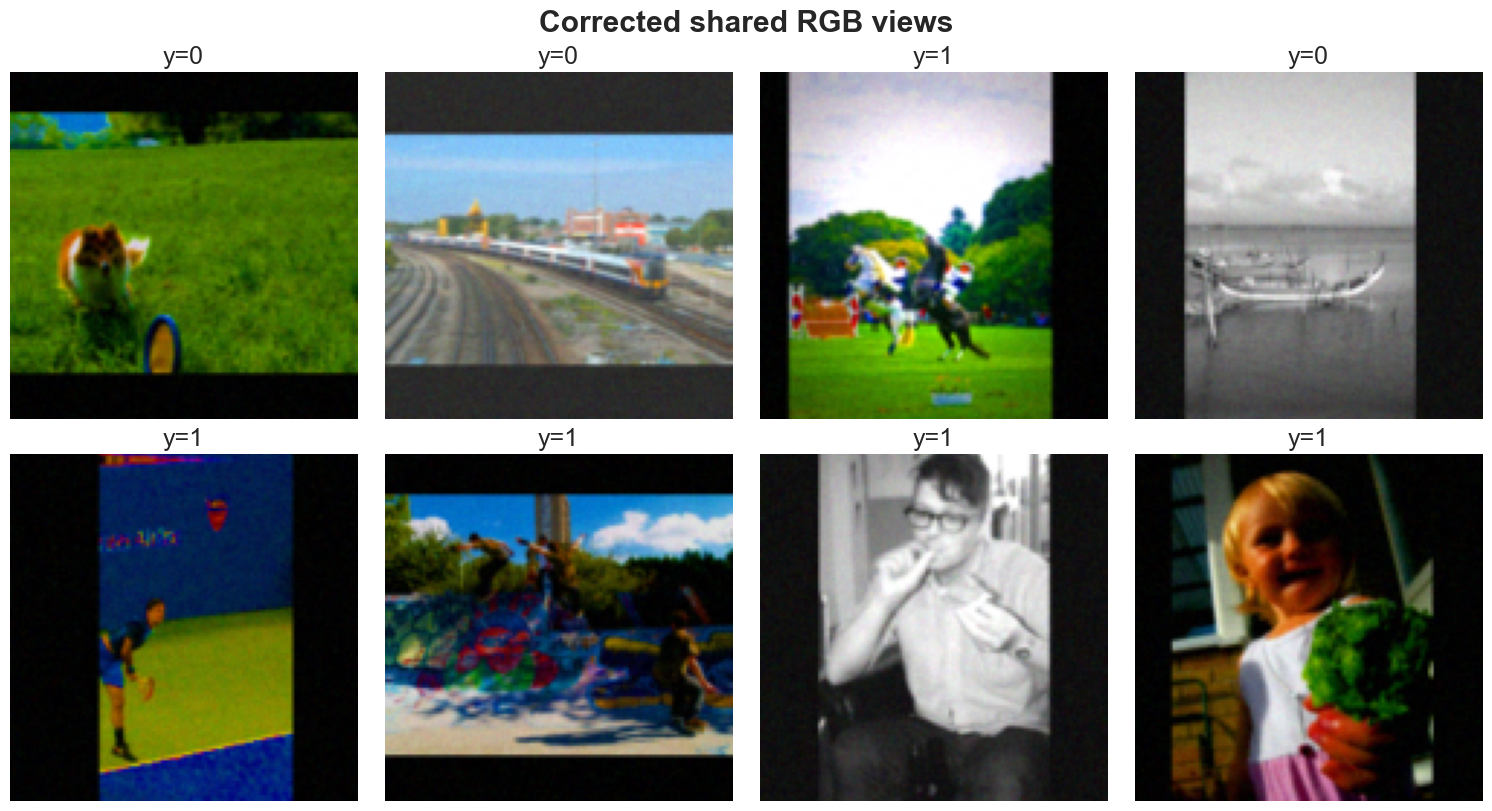

In [10]:
preview_inputs,preview_labels=next(iter(make_dataset(splits["train"].iloc[:8],True,SEED,8)))
fig,axes=plt.subplots(2,4,figsize=(15,8),constrained_layout=True)
for i,ax in enumerate(axes.flat):
    ax.imshow(np.clip(preview_inputs["student_image"][i]/255.,0,1))
    ax.set_title(f"y={int(preview_labels[i,0])}")
    ax.axis("off")
fig.suptitle("Corrected shared RGB views",fontweight="bold")
fig.savefig(FIGURE_DIR/"shared_rgb_views.png",dpi=180)
plt.show()

## 3 · Teacher/student feature-stage audit

In [11]:
teacher=tf.keras.models.load_model(paths["teacher_model"],compile=False)
teacher.trainable=False

In [12]:
external_control=tf.keras.models.load_model(paths["corrected_control_model"],compile=False)

In [13]:
t_layer=config["attention"]["teacher_layer"]
s_layer=config["attention"]["student_layer"]
assert teacher.get_layer(t_layer)
assert external_control.get_layer(s_layer)
stage_audit=pd.DataFrame([
    {"network":"teacher","layer":t_layer,"shape":str(tuple(teacher.get_layer(t_layer).output.shape)),"input":str(teacher.input_shape)},
    {"network":"student","layer":s_layer,"shape":str(tuple(external_control.get_layer(s_layer).output.shape)),"input":str(external_control.input_shape)},
])
stage_audit.to_csv(REPORT_DIR/"attention_stage_audit.csv",index=False)
display(stage_audit)

,network,layer,shape,input
0,teacher,conv_pw_11_relu,"(None, 10, 10, 256)","(None, 160, 160, 3)"
1,student,conv_pw_11_relu,"(None, 7, 7, 128)","(None, 120, 120, 3)"


## 4 · Exact Student-120 and feature taps

In [14]:
def build_student_core(weights="imagenet"):
    inp=tf.keras.Input(
        (*STUDENT_SIZE,3),
        name="image"
    )
    x=tf.keras.layers.Rescaling(
        1/127.5,
        offset=-1,
        name="normalize"
    )(inp)
    backbone=tf.keras.applications.MobileNet(
        input_tensor=x,
        input_shape=(*STUDENT_SIZE,3),
        alpha=float(config["student"]["width_multiplier"]),
        include_top=False,
        weights=weights
    )
    x=tf.keras.layers.GlobalAveragePooling2D(name="global_average")(backbone.output)
    x=tf.keras.layers.Dropout(
        config["student"]["dropout"],
        name="student_dropout"
    )(x)
    logits=tf.keras.layers.Dense(
        1,
        kernel_regularizer=tf.keras.regularizers.l2(config["student"]["l2"]),
        name="person_logit"
    )(x)
    return tf.keras.Model(
        inp,
        logits,
        name="student_120_attention_logits"
    ), backbone

In [15]:
def probability_view(core,name):
    return tf.keras.Model(
        core.input,
        tf.keras.layers.Activation("sigmoid",name="person_probability")(core.output),
        name=name
    )

def feature_view(model,layer_name): 
    return tf.keras.Model(
        model.input,
        [
           model.output,
           model.get_layer(layer_name).output
        ]
    )

def copy_weighted_layers(source,destination):
    src={l.name:l for l in source.layers if l.weights}
    for layer in destination.layers:
        if layer.weights: layer.set_weights(src[layer.name].get_weights())

In [16]:
tf.keras.utils.set_random_seed(SEED)

In [17]:
probe_core, probe_backbone=build_student_core(weights=None)

In [18]:
probe=probability_view(
    probe_core,
    "probe"
)

In [19]:
assert probe.count_params()==external_control.count_params()==218801
layer_table,liveness,static_profile=profile_model(probe,batch_size=1,training_batch_size=BATCH_SIZE)
layer_table.to_csv(REPORT_DIR/"student_layer_profile.csv",index=False)
liveness.to_csv(REPORT_DIR/"student_activation_liveness.csv",index=False)
(REPORT_DIR/"student_static_profile.json").write_text(json.dumps(static_profile,indent=2))
display(pd.Series(static_profile))

model_name                                                                                         probe
layers                                                                                                91
parameters                                                                                        218801
trainable_parameters                                                                              213329
non_trainable_parameters                                                                            5472
float32_weight_bytes                                                                              875204
global_weight_sparsity                                                                          0.025014
global_weight_near_zero_fraction                                                                0.025014
global_kernel_sparsity                                                                               0.0
global_kernel_near_zero_fraction                       

## 5 · Attention mathematics and invariants

In [20]:
EPS=float(config["attention"]["epsilon"])
POWER=float(config["attention"]["power"])

In [21]:
def spatial_attention(
        features,
        target_hw=None
):
    attention=tf.reduce_sum(
        tf.pow(
            tf.abs(tf.cast(features,tf.float32)),
            POWER
        ),
        axis=-1,
        keepdims=True
    )
    if target_hw is not None: attention=tf.image.resize(attention,target_hw,method="bilinear",antialias=True)
    flat=tf.reshape(
        attention,
        [tf.shape(attention)[0],-1]
    )
    # L2
    return tf.math.l2_normalize(
        flat,
        axis=1,
        epsilon=EPS
    )

In [22]:
def attention_loss(
        teacher_features,
        student_features
):
    target_hw=tf.shape(student_features)[1:3]
    t=spatial_attention(
        teacher_features,
        target_hw
    )
    s=spatial_attention(student_features)
    return tf.reduce_mean(
        tf.reduce_sum(tf.square(t-s),axis=1)
    )

probe_feature=tf.random.uniform((2,7,7,8),seed=SEED)
assert float(attention_loss(probe_feature,probe_feature))<1e-7
assert np.isfinite(float(attention_loss(tf.random.uniform((2,10,10,16)),probe_feature)))
print("Attention invariants passed")

Attention invariants passed


## 6 · Shared Stage A and gradient-calibrated Stage B

In [23]:
class BestStudent(tf.keras.callbacks.Callback):
    def __init__(self,path): 
        super().__init__()
        self.path=Path(path)
        self.best=-np.inf

    def on_epoch_end(self,epoch,logs=None):
        value=(logs or {}).get(config["training"]["monitor"])
        if value is not None and float(value)>self.best: self.best=float(value)
        self.model.student_core.save(self.path)

In [24]:
def callbacks(name,path):
    return [
        BestStudent(path),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=config["training"]["early_stopping_patience"]
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc",
            mode="max",
            factor=.3,
            patience=config["training"]["reduce_lr_patience"],
            min_lr=1e-7
        ),
        tf.keras.callbacks.CSVLogger(LOG_DIR/f"{name}.csv"),
        tf.keras.callbacks.TerminateOnNaN()
    ]

In [25]:
class AttentionDistiller(tf.keras.Model):
    def __init__(self,student_core,teacher_model,beta):
        super().__init__()
        self.student_core=student_core
        self.teacher_model=teacher_model
        self.beta=tf.constant(float(beta),tf.float32)
        self.student_features=feature_view(student_core,s_layer)
        self.teacher_features=feature_view(teacher_model,t_layer)
        self.beta_value=float(beta)
        names=["loss","hard_loss","attention_loss","attention_component","hard_gradient_norm","attention_gradient_norm","gradient_cosine"]
        self.track={n:tf.keras.metrics.Mean(name=n) for n in names}
        self.quality=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(curve="PR",name="pr_auc")
        ]

    @property
    def metrics(self): 
        return [*self.track.values(),*self.quality]
    
    def _terms(self,inputs,labels,training):
        logits,sf=self.student_features(
            inputs["student_image"],
            training=training
        )
        if self.beta_value>0: 
            _,tftr=self.teacher_features(
                inputs["teacher_image"],
                training=False
            )
            at=attention_loss(
                tf.stop_gradient(tftr),
                sf
            )
        else: 
            at=tf.constant(0.,tf.float32)

        labels=tf.reshape(labels,(-1,1))
        smooth=labels*(1-config["training"]["label_smoothing"])+.5*config["training"]["label_smoothing"]
        hard=tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(labels=smooth,logits=logits)
        )
        reg=tf.add_n(self.student_core.losses) if self.student_core.losses else 0.
        return logits,hard,at,hard+self.beta*at+reg
    
    def train_step(self,data):
        inputs,labels=data
        
        with tf.GradientTape(persistent=True) as tape:
            logits,hard,at,total=self._terms(inputs,labels,True)
            at_part=self.beta*at
        
            variables=self.student_core.trainable_variables
            grads=tape.gradient(total,variables)
            hg=tape.gradient(hard,variables)
            ag=tape.gradient(at_part,variables)
            del tape

            pairs=[(g,v) for g,v in zip(grads,variables) if g is not None]
            self.optimizer.apply_gradients(pairs)

            # Align gradients by variable. Hard loss also touches the classifier head while
            # attention loss touches only the backbone up to the selected feature stage.
            hv=tf.concat([tf.reshape(g if g is not None else tf.zeros_like(v),[-1]) for g,v in zip(hg,variables)],0)
            av=tf.concat([tf.reshape(g if g is not None else tf.zeros_like(v),[-1]) for g,v in zip(ag,variables)],0)
            cosine=tf.math.divide_no_nan(tf.reduce_sum(hv*av),tf.norm(hv)*tf.norm(av))
        
            vals={
                "loss":total,
                "hard_loss":hard,
                "attention_loss":at,
                "attention_component":at_part,
                "hard_gradient_norm":tf.linalg.global_norm([g for g in hg if g is not None]),
                "attention_gradient_norm":tf.linalg.global_norm([g for g in ag if g is not None]),
                "gradient_cosine":cosine
            }
        
            for n,v in vals.items(): 
                self.track[n].update_state(v)
            for m in self.quality: 
                m.update_state(tf.reshape(labels,(-1,1)),tf.sigmoid(logits))
            return {m.name:m.result() for m in self.metrics}
    
    def test_step(self,data):
        inputs,labels=data
        logits,hard,at,total=self._terms(inputs,labels,False)
        vals={
            "loss":total,
            "hard_loss":hard,
            "attention_loss":at,
            "attention_component":self.beta*at,
            "hard_gradient_norm":0.,
            "attention_gradient_norm":0.,
            "gradient_cosine":0.
        }
        for n,v in vals.items(): 
            self.track[n].update_state(v)
        for m in self.quality: 
            m.update_state(tf.reshape(labels,(-1,1)),tf.sigmoid(logits))
        return {m.name:m.result() for m in self.metrics}

In [26]:
# One shared head-training checkpoint; attention is inactive while the backbone is frozen.
STAGE_A=CHECKPOINT_DIR/"shared_stage_a.keras"

In [27]:
if RUN_TRAINING and not (REUSE_CHECKPOINTS and STAGE_A.exists()):
    tf.keras.utils.set_random_seed(SEED)
    stage_core,stage_backbone=build_student_core()
    for layer in stage_core.layers:
        if layer.name in {l.name for l in stage_backbone.layers}: 
           layer.trainable=False
    trainer=AttentionDistiller(
        stage_core,
        teacher,
        beta=0.
    )
    trainer.compile(
        optimizer=tf.keras.optimizers.Adam(config["training"]["head_learning_rate"])
    )
    trainer.fit(
        make_dataset(splits["train"],True,SEED),
        validation_data=make_dataset(splits["val"],False,SEED),
        epochs=config["training"]["head_epochs"],
        callbacks=callbacks("shared_stage_a",STAGE_A)
    )
assert STAGE_A.exists()

/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/ipykernel_1773/3445979447.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone=tf.keras.applications.MobileNet(


Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 202ms/step - accuracy: 0.5164 - attention_component: 0.0000e+00 - attention_gradient_norm: 0.0000e+00 - attention_loss: 0.0000e+00 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 3.0963 - hard_loss: 0.9654 - loss: 0.9655 - pr_auc: 0.5196 - precision: 0.5173 - recall: 0.4903 - val_accuracy: 0.6150 - val_attention_component: 0.0000e+00 - val_attention_gradient_norm: 0.0000e+00 - val_attention_loss: 0.0000e+00 - val_gradient_cosine: 0.0000e+00 - val_hard_gradient_norm: 0.0000e+00 - val_hard_loss: 0.7225 - val_loss: 0.7226 - val_pr_auc: 0.6238 - val_precision: 0.6024 - val_recall: 0.6512 - learning_rate: 3.0000e-04
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 76s 201ms/step - accuracy: 0.6154 - attention_component: 0.0000e+00 - attention_gradient_norm: 0.0000e+00 - attention_loss: 0.0000e+00 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 2.4915 - hard_loss: 0.7380 - loss: 0.7380 - pr_auc: 0.6579 - precision: 0.6153 - recall: 0.6160 - val_accura

In [28]:
def unfreeze_tail(core):
    mobile_names=[l.name for l in core.layers if l.name.startswith("conv_")]
    cutoff=max(0,len(mobile_names)-config["training"]["fine_tune_last_layers"])
    selected=set(mobile_names[cutoff:])
    for layer in core.layers:
        if layer.name in selected: 
            layer.trainable=not isinstance(layer,tf.keras.layers.BatchNormalization)
    return core

In [29]:
def calibrate_beta(core,batch,target_ratio):
    inputs,labels=batch
    sfm=feature_view(core,s_layer)
    tfm=feature_view(teacher,t_layer)
    with tf.GradientTape(persistent=True) as tape:
        logits,sf=sfm(inputs["student_image"],training=True)
        _,tftr=tfm(inputs["teacher_image"],training=False)
        labels=tf.reshape(labels,(-1,1))
        hard=tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(labels=labels,logits=logits)
        )
        raw_at=attention_loss(
            tf.stop_gradient(tftr),
            sf
        )
    
    variables=core.trainable_variables
    hg=tape.gradient(hard,variables)
    ag=tape.gradient(raw_at,variables)
    del tape
    hn=float(tf.linalg.global_norm([g for g in hg if g is not None]))
    an=float(tf.linalg.global_norm([g for g in ag if g is not None]))
    beta=np.clip(
        target_ratio*hn/max(an,1e-12),
        config["attention"]["beta_minimum"],
        config["attention"]["beta_maximum"]
    )
    return float(beta),{"hard_gradient_norm":hn,"raw_attention_gradient_norm":an,"target_ratio":target_ratio}

calibration_core=unfreeze_tail(
    tf.keras.models.load_model(STAGE_A,compile=False)
)
calibration_batch=next(iter(make_dataset(splits["train"].iloc[:BATCH_SIZE],True,SEED)))
BETA,beta_audit=calibrate_beta(
    calibration_core,
    calibration_batch,
    config["attention"]["target_gradient_ratio"]
)
beta_audit["beta"]=BETA
(REPORT_DIR/"beta_calibration.json").write_text(json.dumps(beta_audit,indent=2))
print(beta_audit)

{'hard_gradient_norm': 8.984138488769531, 'raw_attention_gradient_norm': 0.19728991389274597, 'target_ratio': 0.1, 'beta': 4.553774854224752}


In [30]:
def train_branch(name,beta):
    path=CHECKPOINT_DIR/f"{name}_stage_b.keras"; core=unfreeze_tail(tf.keras.models.load_model(STAGE_A,compile=False))
    if RUN_TRAINING and not (REUSE_CHECKPOINTS and path.exists()):
        trainer=AttentionDistiller(
            core,
            teacher,
            beta
        )
        trainer.compile(optimizer=tf.keras.optimizers.Adam(config["training"]["fine_tune_learning_rate"]))
        trainer.fit(make_dataset(splits["train"],True,SEED),validation_data=make_dataset(splits["val"],False,SEED),epochs=config["training"]["fine_tune_epochs"],callbacks=callbacks(name,path))
    core=tf.keras.models.load_model(path,compile=False)
    model=probability_view(core,name)
    model_path=MODEL_DIR/f"{name}.keras"
    model.save(model_path)
    return model_path

models={
    "attention_control":train_branch("attention_control",0.),
    "attention_transfer":train_branch("attention_transfer",BETA)
}
models

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 87s 225ms/step - accuracy: 0.7155 - attention_component: 0.0000e+00 - attention_gradient_norm: 0.0000e+00 - attention_loss: 0.0000e+00 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 9.8392 - hard_loss: 0.5672 - loss: 0.5672 - pr_auc: 0.7979 - precision: 0.7220 - recall: 0.7008 - val_accuracy: 0.7465 - val_attention_component: 0.0000e+00 - val_attention_gradient_norm: 0.0000e+00 - val_attention_loss: 0.0000e+00 - val_gradient_cosine: 0.0000e+00 - val_hard_gradient_norm: 0.0000e+00 - val_hard_loss: 0.5281 - val_loss: 0.5281 - val_pr_auc: 0.8250 - val_precision: 0.7745 - val_recall: 0.6876 - learning_rate: 3.0000e-05
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 219ms/step - accuracy: 0.7214 - attention_component: 0.0000e+00 - attention_gradient_norm: 0.0000e+00 - attention_loss: 0.0000e+00 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 9.0712 - hard_loss: 0.5547 - loss: 0.5547 - pr_auc: 0.8054 - precision: 0.7306 - recall: 0.7015 - val_accu

{'attention_control': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/attention_transfer_student_120/models/attention_control.keras'),
 'attention_transfer': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/attention_transfer_student_120/models/attention_transfer.keras')}

## 7 · Optimization and gradient diagnostics

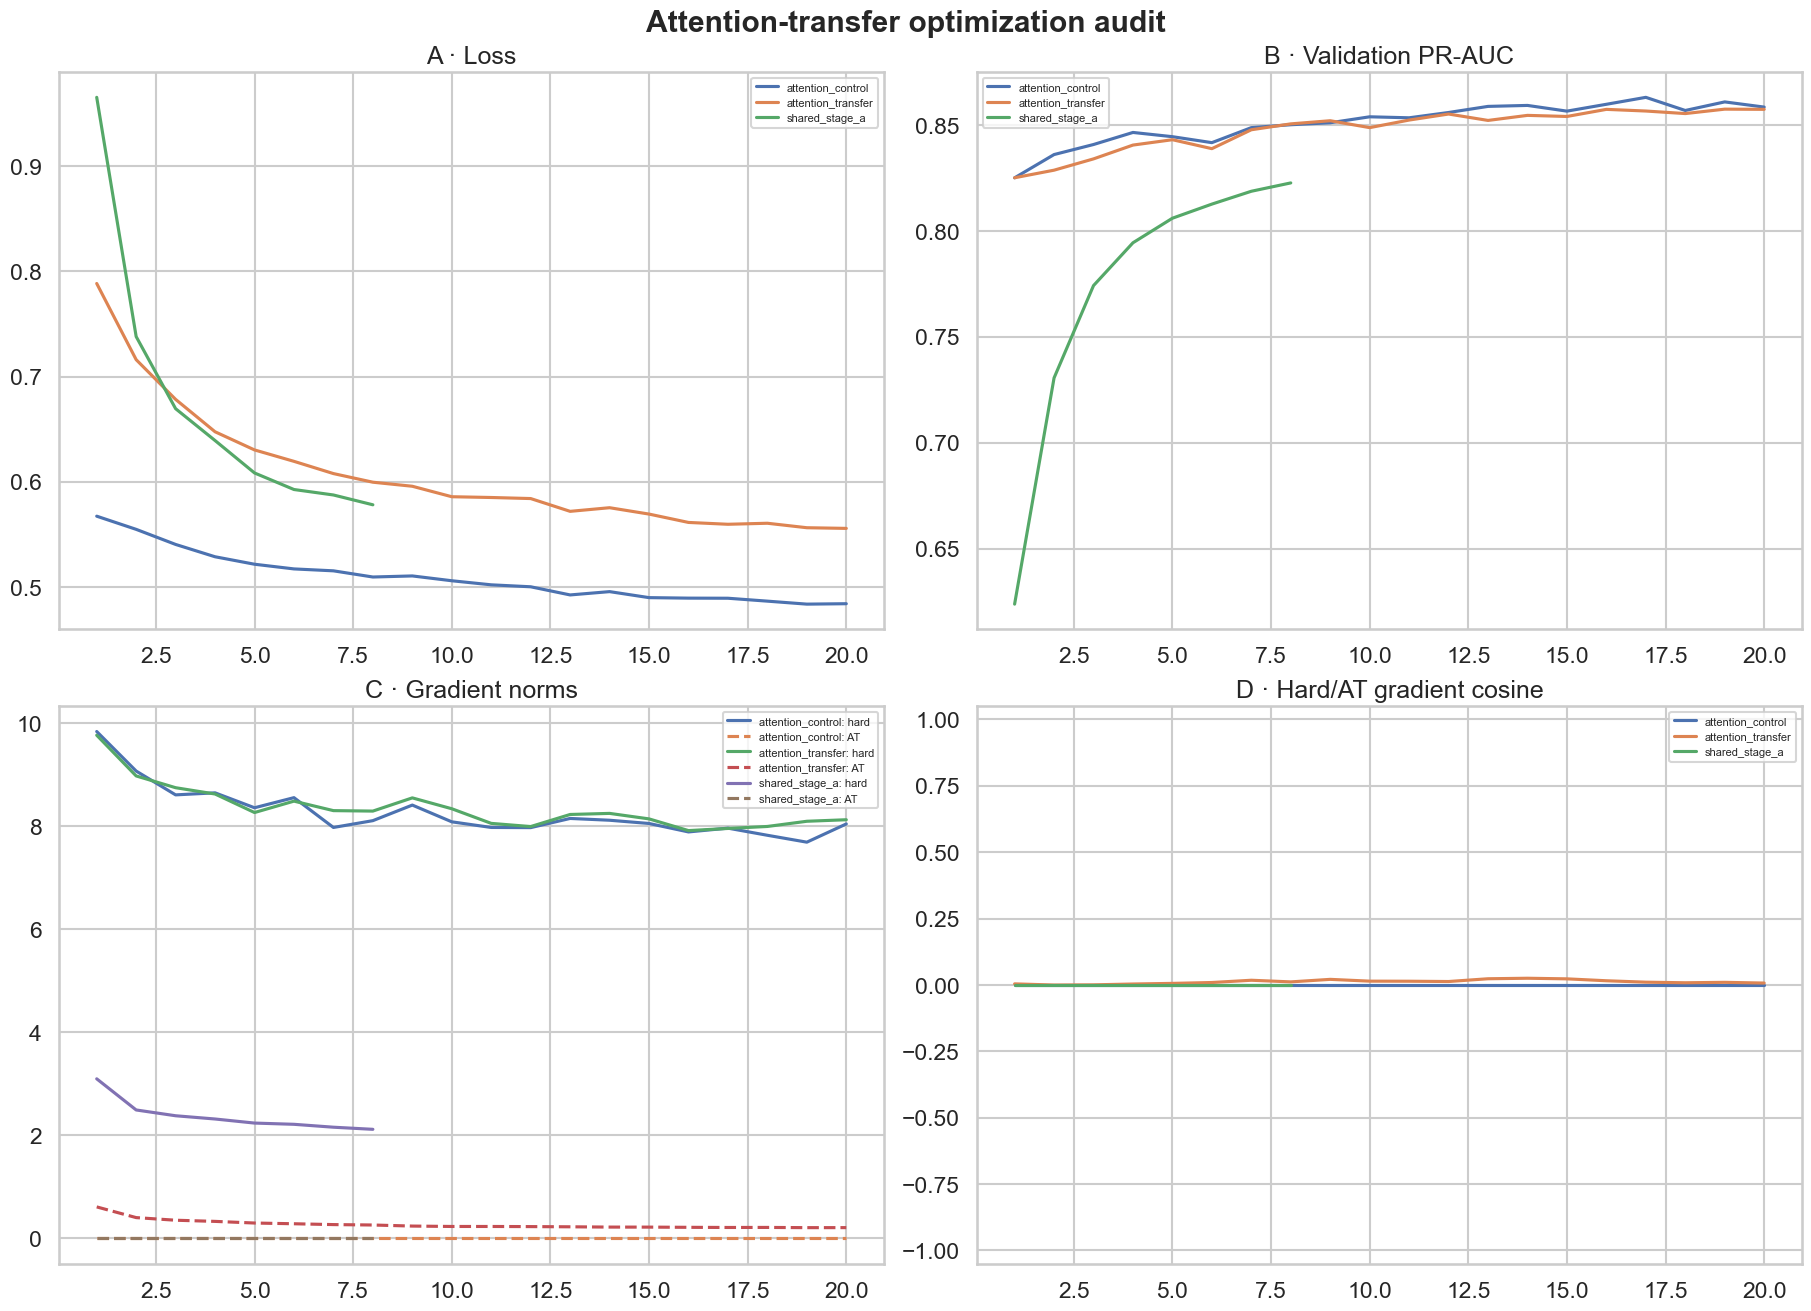

In [31]:
logs=[]
for name in ("shared_stage_a","attention_control","attention_transfer"):
    p=LOG_DIR/f"{name}.csv"
    if p.exists(): d=pd.read_csv(p); d["run"]=name; d["epoch_index"]=np.arange(len(d))+1; logs.append(d)
history=pd.concat(logs,ignore_index=True)
history.to_csv(REPORT_DIR/"training_history.csv",index=False)
fig,axes=plt.subplots(2,2,figsize=(18,13),constrained_layout=True)
for name,d in history.groupby("run"):
    axes[0,0].plot(d.epoch_index,d.loss,label=name); axes[0,1].plot(d.epoch_index,d.val_pr_auc,label=name)
    axes[1,0].plot(d.epoch_index,d.hard_gradient_norm,label=f"{name}: hard")
    axes[1,0].plot(d.epoch_index,d.attention_gradient_norm,"--",label=f"{name}: AT")
    axes[1,1].plot(d.epoch_index,d.gradient_cosine,label=name)
axes[0,0].set_title("A · Loss")
axes[0,1].set_title("B · Validation PR-AUC")
axes[1,0].set_title("C · Gradient norms")
axes[1,1].set_title("D · Hard/AT gradient cosine")
axes[1,1].set_ylim(-1.05,1.05)
for ax in axes.flat: ax.legend(fontsize=8)
fig.suptitle("Attention-transfer optimization audit",fontweight="bold")
fig.savefig(FIGURE_DIR/"attention_training_audit.png",dpi=180)
plt.show()

## 8 · Validation-selected frozen-test comparison

In [32]:
def eval_dataset(frame):
    ds=tf.data.Dataset.from_tensor_slices((frame.image_path.astype(str),frame.label.astype("float32")))
    return ds.map(lambda p,y:(tf.image.resize_with_pad(decode_rgb(p),*STUDENT_SIZE,antialias=True),y),num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

def predict(model,ds): 
    return np.concatenate([np.asarray(y).reshape(-1) for _,y in ds]).astype(int),np.asarray(model.predict(ds,verbose=0)).reshape(-1)

val_ds=eval_dataset(splits["val"])
test_ds=eval_dataset(splits["test"])
rows=[]
probabilities={}
thresholds={}
for name,path in models.items():
    model=tf.keras.models.load_model(path,compile=False)
    vy,vp=predict(model,val_ds)
    ty,tp=predict(model,test_ds)
    threshold=select_threshold(
        vy,
        vp,
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=config["evaluation"]["minimum_recall"],
        false_positive_cost=1.,
        false_negative_cost=2.
    )["threshold"]
    metrics=classification_metrics(
        ty,
        tp,
        threshold
    )
    metrics["ece_10"]=expected_calibration_error(ty,tp)
    rows.append({"model":name,**metrics})
    probabilities[name]=tp
    thresholds[name]=threshold
    test_labels=ty

quality=pd.DataFrame(rows); quality.to_csv(REPORT_DIR/"quality_comparison.csv",index=False); display(quality)

,model,samples,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,confusion_matrix,positive_prevalence,predicted_positive_rate,ece_10
0,attention_control,2000,0.405,0.773,0.750714,0.804281,0.776575,0.860413,0.863304,0.742885,"[[757, 262], [192, 789]]",0.4905,0.5255,0.016567
1,attention_transfer,2000,0.395,0.766,0.734247,0.819572,0.774566,0.861291,0.861767,0.714426,"[[728, 291], [177, 804]]",0.4905,0.5475,0.015842


In [33]:
rng=np.random.default_rng(SEED)
records=[]
idx=np.arange(len(test_labels))

In [34]:
for iteration in range(config["evaluation"]["bootstrap_samples"]):
    draw=rng.choice(idx,len(idx),replace=True)
    y=test_labels[draw]
    c=probabilities["attention_control"][draw]
    a=probabilities["attention_transfer"][draw]
    records.append({"iteration":iteration,"pr_auc_delta":average_precision_score(y,a)-average_precision_score(y,c),"f1_delta":f1_score(y,a>=thresholds["attention_transfer"])-f1_score(y,c>=thresholds["attention_control"])})
bootstrap=pd.DataFrame(records)
bootstrap.to_csv(REPORT_DIR/"paired_bootstrap.csv",index=False)
summary=[]
for metric in ("pr_auc_delta","f1_delta"):
    v=bootstrap[metric]
    summary.append({"metric":metric,"mean":v.mean(),"ci_low":v.quantile(.025),"ci_high":v.quantile(.975),"probability_positive":(v>0).mean()})
bootstrap_summary=pd.DataFrame(summary)
display(bootstrap_summary)
bootstrap_summary.to_csv(REPORT_DIR/"bootstrap_summary.csv",index=False)

,metric,mean,ci_low,ci_high,probability_positive
0,pr_auc_delta,-0.001378,-0.007026,0.004124,0.316
1,f1_delta,-0.002286,-0.013229,0.008178,0.320


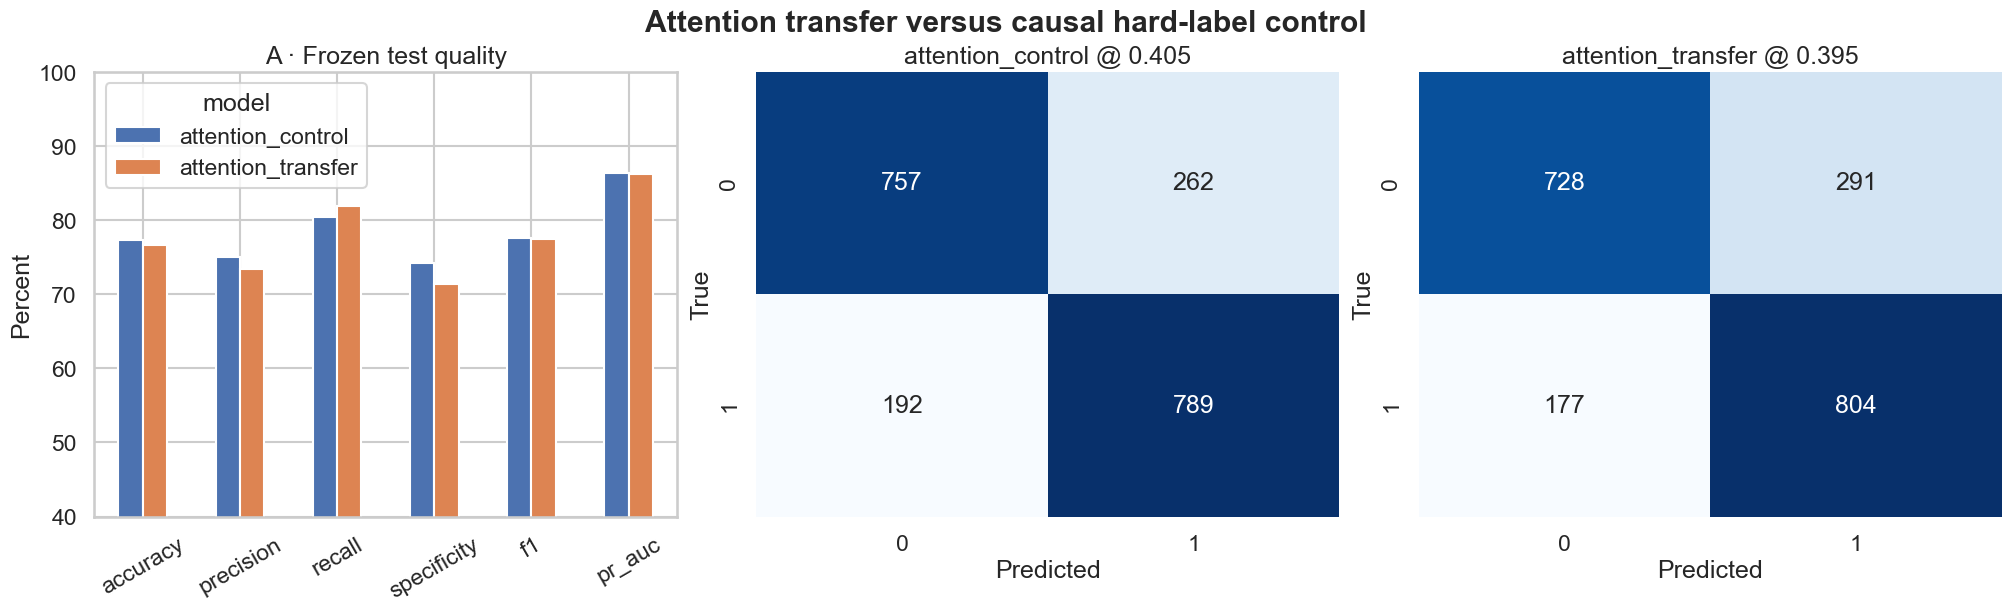

In [35]:
fig,axes=plt.subplots(1,3,figsize=(20,6),constrained_layout=True)
metrics=["accuracy","precision","recall","specificity","f1","pr_auc"]
(quality.set_index("model")[metrics].T*100).plot(kind="bar",ax=axes[0])
axes[0].set(title="A · Frozen test quality",ylabel="Percent",ylim=(40,100))
axes[0].tick_params(axis="x",rotation=30)
for axis,(name,row) in zip(axes[1:],quality.set_index("model").iterrows()):
    matrix=np.asarray(row.confusion_matrix)
    sns.heatmap(matrix,annot=True,fmt="d",cmap="Blues",cbar=False,ax=axis)
    axis.set(title=f"{name} @ {row.threshold:.3f}",xlabel="Predicted",ylabel="True")
fig.suptitle("Attention transfer versus causal hard-label control",fontweight="bold")
fig.savefig(FIGURE_DIR/"attention_quality_dashboard.png",dpi=180,bbox_inches="tight")
plt.show()

## 9 · Spatial-attention evidence

In [36]:
control=tf.keras.models.load_model(models["attention_control"],compile=False)
at_model=tf.keras.models.load_model(models["attention_transfer"],compile=False)

In [37]:
tfm=feature_view(teacher,t_layer)
cfm=feature_view(control,s_layer)
afm=feature_view(at_model,s_layer)

In [38]:
sample_inputs,sample_labels=next(iter(make_dataset(
    splits["test"].iloc[:6],
    False,
    SEED,
    6
)))

In [39]:
_,tfeat=tfm(sample_inputs["teacher_image"],training=False)
_,cfeat=cfm(sample_inputs["student_image"],training=False)
_,afeat=afm(sample_inputs["student_image"],training=False)

In [40]:
def maps(f,target=None):
    m=tf.reduce_sum(tf.square(f),axis=-1,keepdims=True)
    if target is not None: 
        m=tf.image.resize(m,target)
    m=m-tf.reduce_min(m,axis=[1,2],keepdims=True)
    return m/(tf.reduce_max(m,axis=[1,2],keepdims=True)+1e-6)

In [41]:
tm=maps(tfeat,tf.shape(cfeat)[1:3]).numpy()
cm=maps(cfeat).numpy()
am=maps(afeat).numpy()

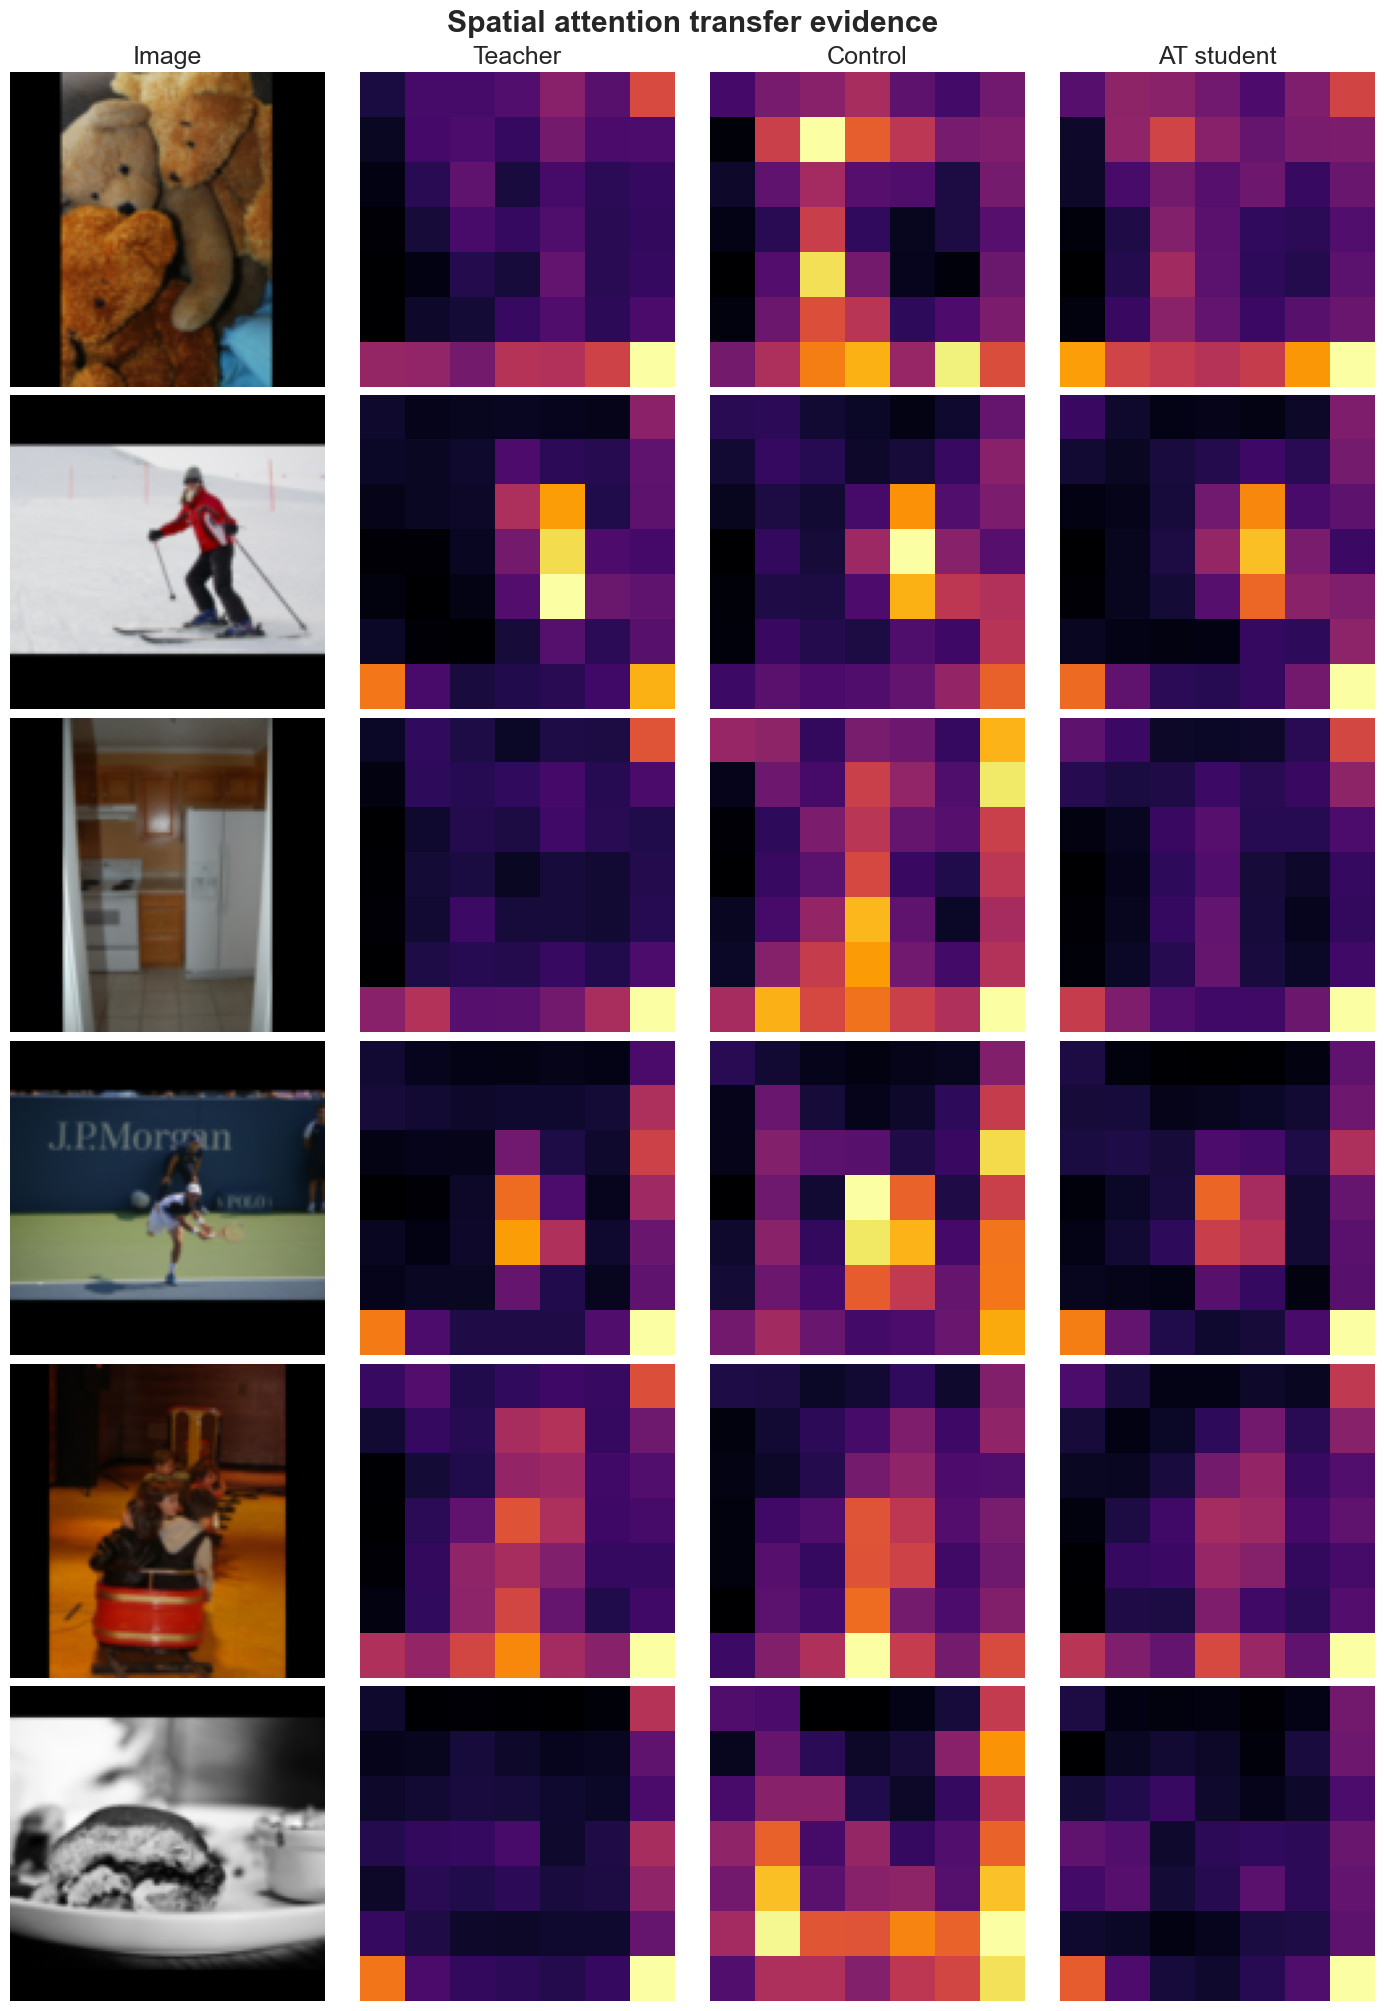

In [42]:
fig,axes=plt.subplots(6,4,figsize=(14,20),constrained_layout=True)
for i in range(6):
    axes[i,0].imshow(np.clip(sample_inputs["student_image"][i]/255.,0,1)); axes[i,1].imshow(tm[i,:,:,0],cmap="inferno"); axes[i,2].imshow(cm[i,:,:,0],cmap="inferno"); axes[i,3].imshow(am[i,:,:,0],cmap="inferno")
    for ax in axes[i]: ax.axis("off")
axes[0,0].set_title("Image"); axes[0,1].set_title("Teacher"); axes[0,2].set_title("Control"); axes[0,3].set_title("AT student")
fig.suptitle("Spatial attention transfer evidence",fontweight="bold"); fig.savefig(FIGURE_DIR/"attention_map_comparison.png",dpi=180); plt.show()

## 10 · Graph invariance, acceptance, and conditional INT8 export

In [43]:
profiles=[]
for name,path in models.items():
    model=tf.keras.models.load_model(path,compile=False)
    _,_,p=profile_model(model,batch_size=1,training_batch_size=BATCH_SIZE)
    profiles.append({"model":name,"parameters":p["parameters"],"macs":p["estimated_macs_batch1"],"peak_int8_activation":p["peak_live_activation_int8_bytes_batch1_hypothetical"]})
graph=pd.DataFrame(profiles)
graph.to_csv(REPORT_DIR/"graph_identity.csv",index=False)
display(graph)
q=quality.set_index("model")
control_row=q.loc["attention_control"]
at_row=q.loc["attention_transfer"]
gates={"pr_auc_gain":bool(at_row.pr_auc>=control_row.pr_auc+config["acceptance_gate"]["minimum_pr_auc_gain"]),"f1_retained":bool(at_row.f1>=control_row.f1-config["acceptance_gate"]["maximum_f1_drop"]),"specificity_retained":bool(at_row.specificity>=control_row.specificity-config["acceptance_gate"]["maximum_specificity_drop"]),"graph_identity":bool(graph.drop(columns="model").nunique().max()==1)}
gates["accepted_float"]=all(gates.values()); (REPORT_DIR/"acceptance_gates.json").write_text(json.dumps(gates,indent=2)); print(gates)

,model,parameters,macs,peak_int8_activation
0,attention_control,218801,10487648,117136
1,attention_transfer,218801,10487648,117136


{'pr_auc_gain': False, 'f1_retained': True, 'specificity_retained': False, 'graph_identity': True, 'accepted_float': False}


In [44]:
TFLITE_PATH=MODEL_DIR/config["export"]["model_filename"]
def representative():
   count=0
   for images,_ in val_ds:
      for image in images:
         yield [image.numpy()[None].astype(np.float32)]; count+=1
         if count>=config["export"]["representative_samples"]: 
            return
if gates["accepted_float"] and RUN_INT8_EXPORT:
   convert_full_integer(tf.keras.models.load_model(models["attention_transfer"],compile=False),representative(),TFLITE_PATH)
   export_info=inspect_tflite(TFLITE_PATH); (REPORT_DIR/"export_info.json").write_text(json.dumps(export_info,indent=2)); display(pd.Series(export_info))
else: 
   export_info=None
   print("INT8 export skipped: float attention-transfer gates did not pass.")

INT8 export skipped: float attention-transfer gates did not pass.


In [45]:
def predict_tflite(path,dataset):
 interpreter=tf.lite.Interpreter(model_path=str(path)); interpreter.allocate_tensors()
 inp=interpreter.get_input_details()[0]; out=interpreter.get_output_details()[0]
 ins,inz=inp["quantization"]; outs,outz=out["quantization"]; labels=[]; probabilities=[]
 for images,batch_labels in dataset:
  labels.extend(np.asarray(batch_labels).reshape(-1).astype(int))
  for image in np.asarray(images):
   q=np.clip(np.round(image/ins+inz),-128,127).astype(np.int8)[None]
   interpreter.set_tensor(inp["index"],q); interpreter.invoke(); raw=interpreter.get_tensor(out["index"])[0,0]
   probabilities.append((float(raw)-outz)*outs)
 return np.asarray(labels),np.asarray(probabilities)
if export_info:
 _,ivp=predict_tflite(TFLITE_PATH,val_ds); _,itp=predict_tflite(TFLITE_PATH,test_ds)
 int8_threshold=select_threshold(vy,ivp,objective=config["evaluation"]["threshold_objective"],minimum_recall=config["evaluation"]["minimum_recall"],false_positive_cost=1.,false_negative_cost=2.)["threshold"]
 int8_metrics=classification_metrics(test_labels,itp,int8_threshold)
 parity={"probability_mae":float(np.mean(np.abs(itp-probabilities["attention_transfer"]))),"f1_delta":float(int8_metrics["f1"]-at_row.f1),"pr_auc_delta":float(int8_metrics["pr_auc"]-at_row.pr_auc)}
 parity["passed"]=bool(parity["probability_mae"]<=config["acceptance_gate"]["maximum_float_to_int8_probability_mae"])
 (REPORT_DIR/"int8_metrics.json").write_text(json.dumps(int8_metrics,indent=2)); (REPORT_DIR/"float_to_int8_parity.json").write_text(json.dumps(parity,indent=2)); print({"int8":int8_metrics,"parity":parity})
else: int8_metrics=None; parity=None

## 11 · Final report

In [47]:
pip install tabulate


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
summary={"experiment":config["project"]["name"],"contract":contract,"beta_calibration":beta_audit,"quality":quality.to_dict("records"),"bootstrap":bootstrap_summary.to_dict("records"),"graph":graph.to_dict("records"),"gates":gates,"int8_export":export_info,"int8_metrics":int8_metrics,"float_to_int8_parity":parity,"physical_profile_complete":False}
(REPORT_DIR/"experiment_summary.json").write_text(json.dumps(summary,indent=2))
lines=["# Attention-transfer report","",f"- Calibrated beta: **{BETA:.6g}**",f"- Float accepted: **{gates['accepted_float']}**",f"- Physical profiling complete: **False**","","## Quality","",quality.to_markdown(index=False),"","## Gates","",pd.Series(gates).to_markdown(),""]
(REPORT_DIR/"ATTENTION_TRANSFER_REPORT.md").write_text("\n".join(lines)); print(REPORT_DIR/"ATTENTION_TRANSFER_REPORT.md")

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/attention_transfer_student_120/reports/ATTENTION_TRANSFER_REPORT.md


## Next decision

- If attention transfer improves PR-AUC while retaining F1 and specificity, export and profile the
  exact INT8 student on both ESP32 targets.
- If attention maps improve but global quality is neutral, inspect small-person and false-positive
  slices before combining attention with response KD.
- If spatial transfer is ineffective, retain the result and move to FitNets feature hints.